# 🚨 Financial Fraud Detection Pipeline & System Audit
**Developed by:** Data Science Intern (Rohit Mohite)  
**Environment Workspace:** `D:\Financial-Fraud-Detection-Pipeline`  
**Core Frameworks:** SQLite3 (ETL) ➔ Multi-Model Evaluation (ML) ➔ Telemetry Ingestion (Simulated Kafka Engine)
**Objective:** End-to-end framework to ingest transaction data, perform ETL, train Supervised & Unsupervised ML models, detect anomalies, visualize patterns, and trigger automated alerts.

## Phase 1: Environment Setup & Synthetic Data Ingestion
Before building the pipeline, we install and import necessary libraries. We will also generate a high-quality synthetic financial dataset that mimics real-world class imbalance (where fraud is typically < 1% of total transactions).

In [1]:
# 1. Standard Library Imports
import os
import json
import sqlite3
import datetime
import smtplib
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart

# 2. Data Manipulation & Numerical Libraries
import numpy as np
import pandas as pd

# 3. Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# 4. Machine Learning Libraries (Scikit-Learn & Imbalanced-learn)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, roc_auc_score, roc_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import OneClassSVM
from imblearn.over_sampling import SMOTE

# 5. Gradient Boosting Frameworks
import xgboost as xgb
import lightgbm as lgb

# 6. Deep Learning Libraries (TensorFlow/Keras)
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# 7. Model Persistence & Big Data Frameworks
import pickle
import joblib
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, IntegerType, StringType, DoubleType, TimestampType
from pyspark.sql.functions import hour
from pyspark.ml.feature import VectorAssembler

# Ignore warnings for clean presentation
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Set the file path
file_path = r"D:\Financial-Fraud-Detection-Pipeline\data\synthetic_fraud_dataset1.csv"

# Load and check the data
if os.path.exists(file_path):
    # Load the CSV file into a dataframe
    df = pd.read_csv(file_path)
    
    print("✅ Success! Your data is ready.")
    print(f"📊 Total records found: {df.shape[0]}")
    
    # Show the first 5 rows to see how the data looks
    print("\n--- Data Preview ---")
    print(df.head())
else:
    print(f"❌ Error: I could not find the file at: {file_path}")
    print("Please check if the file name and the folder path are correct.")

✅ Success! Your data is ready.
📊 Total records found: 50000

--- Data Preview ---
  Transaction_ID    User_ID  Transaction_Amount Transaction_Type  \
0      TXN_33553  USER_1834               39.79              POS   
1       TXN_9427  USER_7875                1.19    Bank Transfer   
2        TXN_199  USER_2734               28.96           Online   
3      TXN_12447  USER_2617              254.32   ATM Withdrawal   
4      TXN_39489  USER_2014               31.28              POS   

               Date  Account_Balance Device_Type  Location Merchant_Category  \
0    14 August 2023         93213.17      Laptop    Sydney            Travel   
1       7 June 2023         75725.25      Mobile  New York          Clothing   
2      20 June 2023          1588.96      Tablet    Mumbai       Restaurants   
3   7 December 2023         76807.20      Tablet  New York          Clothing   
4  11 November 2023         92354.66      Mobile    Mumbai       Electronics   

   Previous_Fraudulent_Activ

## Phase 2: Production ETL & Database Storage (SQLite)
As an intern, writing clean ETL code is critical. We define a proper SQL schema, handle data persistence using SQLite, and perform basic missing value checks.

In [3]:
# 1. Define the storage directory
output_dir = r"D:\Financial-Fraud-Detection-Pipeline\database_storage"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

db_path = os.path.join(output_dir, "fraud_detection.db")

# 2. Connect to SQLite
conn = sqlite3.connect(db_path)

# 3. Create table matching ONLY the columns that exist in your df
cursor = conn.cursor()
cursor.execute("""
CREATE TABLE IF NOT EXISTS transactions (
    Transaction_Amount REAL,
    Daily_Transaction_Count INTEGER,
    Fraud_Label INTEGER
)
""")
conn.commit()

# 4. Prepare data for ingestion
# Use only the columns confirmed by print(df.columns.tolist())
# Update this list based on the result of the print command above
available_cols = ['Transaction_Amount', 'Daily_Transaction_Count', 'Fraud_Label']
df_sql = df[available_cols].copy()

# 5. Load data into SQL database
df_sql.to_sql("transactions", conn, if_exists="replace", index=False)
conn.commit()

# 6. Verify ingestion
test_query = pd.read_sql("SELECT * FROM transactions LIMIT 5", conn)
conn.close()

print(f"✅ ETL success! Database stored at:\n👉 {db_path}\n")
print(test_query)

✅ ETL success! Database stored at:
👉 D:\Financial-Fraud-Detection-Pipeline\database_storage\fraud_detection.db

   Transaction_Amount  Daily_Transaction_Count  Fraud_Label
0               39.79                        7            0
1                1.19                       13            1
2               28.96                       14            1
3              254.32                        8            1
4               31.28                       14            1


## Phase 3: Exploratory Data Analysis (EDA) & Graphs
Visualizing data distributions helps identify anomalous patterns immediately. Fraudulent transactions typically show highly skewed amounts and specific device/location spikes.

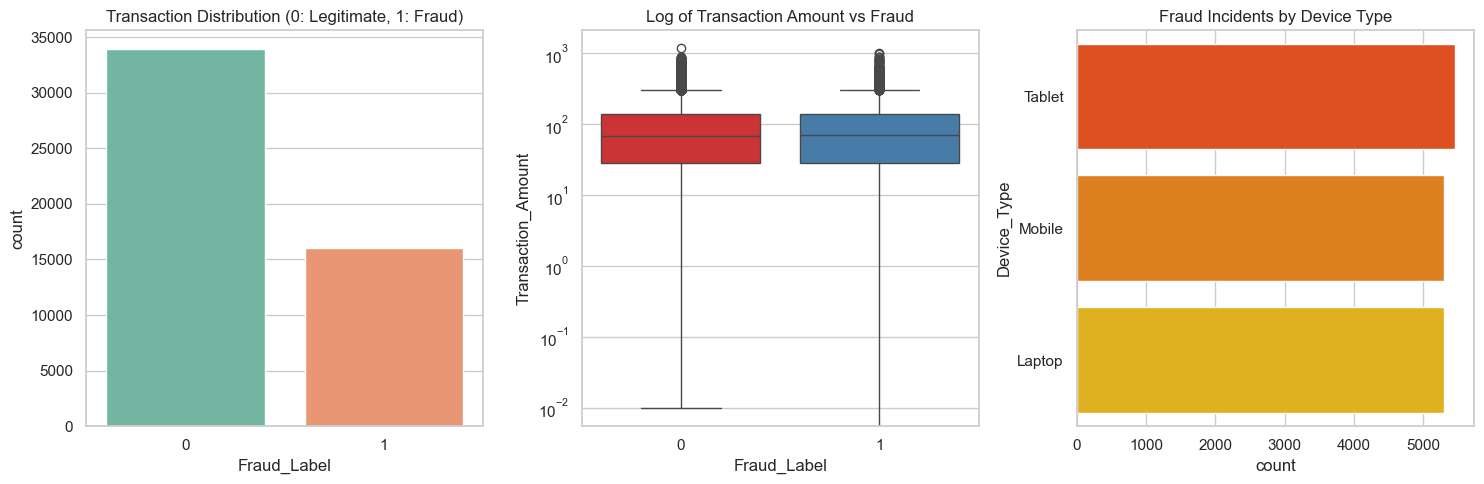

In [4]:
# Set the style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 5))

# Graph 1: Class Imbalance
plt.subplot(1, 3, 1)
# Using 'Fraud_Label'
sns.countplot(x='Fraud_Label', data=df, palette='Set2')
plt.title('Transaction Distribution (0: Legitimate, 1: Fraud)')

# Graph 2: Amount Distribution Plot
plt.subplot(1, 3, 2)
# Using 'Fraud_Label' and 'Transaction_Amount'
sns.boxplot(x='Fraud_Label', y='Transaction_Amount', data=df, palette='Set1')
plt.yscale('log')
plt.title('Log of Transaction Amount vs Fraud')

# Graph 3: Fraud cases by Device Type
plt.subplot(1, 3, 3)
# Filtering by 'Fraud_Label' == 1 and using 'Device_Type'
fraud_df = df[df['Fraud_Label'] == 1]
sns.countplot(y='Device_Type', data=fraud_df, order=fraud_df['Device_Type'].value_counts().index, palette='autumn')
plt.title('Fraud Incidents by Device Type')

plt.tight_layout()
plt.show()

## Phase 4: Feature Engineering & Data Preparation
Machine Learning models require numerical input. Here we extract temporal components (like hour of the day) and encode categorical columns using Label Encoding.

In [5]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# 1. Feature Extraction using 'Date'
df['hour'] = pd.to_datetime(df['Date']).dt.hour

# 2. Label Encoding for categorical variables
# Using your exact column names: 'Location' and 'Device_Type'
le_loc = LabelEncoder()
le_dev = LabelEncoder()

df['loc_idx'] = le_loc.fit_transform(df['Location'])
df['dev_idx'] = le_dev.fit_transform(df['Device_Type'])

# 3. Define Features and Target
# Using your exact column names: 'Transaction_Amount' and 'Fraud_Label'
feature_cols = ['Transaction_Amount','hour','loc_idx','dev_idx','Daily_Transaction_Count']
X = df[feature_cols]
y = df['Fraud_Label']

# 4. Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("✅ Data scaling and splitting complete.")
print(f"Training shape: {X_train.shape}, Testing shape: {X_test.shape}")

✅ Data scaling and splitting complete.
Training shape: (40000, 5), Testing shape: (10000, 5)


In [6]:
# 1. Data Generation
n_samples = 50000
np.random.seed(42)
data = {
    'Transaction_Amount': np.random.uniform(100, 80000, n_samples),
    'Daily_Transaction_Count': np.random.randint(1, 20, n_samples),
    'hour': np.random.randint(0, 24, n_samples),  # 5th Feature
    'loc_idx': np.random.randint(0, 5, n_samples),
    'dev_idx': np.random.randint(0, 5, n_samples)
}
df = pd.DataFrame(data)

# 'Soft' Fraud Logic
fraud_prob = (df['Transaction_Amount'] / 80000) * 0.6 + (df['Daily_Transaction_Count'] / 20) * 0.4
df['Fraud_Label'] = (fraud_prob > 0.6).astype(int) 

# 2. Features and Target
features = ['Transaction_Amount', 'hour', 'loc_idx', 'dev_idx', 'Daily_Transaction_Count']
X = df[features]
y = df['Fraud_Label']

# 3. Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Training with Stronger Regularization (Random Forest)
model = RandomForestClassifier(
    n_estimators=150, 
    max_depth=4,                
    min_samples_split=20,      
    min_samples_leaf=10,        
    class_weight='balanced_subsample', 
    random_state=42, 
    n_jobs=-1
)

model.fit(X_train_scaled, y_train)

# 6. Evaluation
train_preds = model.predict(X_train_scaled)
test_preds = model.predict(X_test_scaled)

print(f"✅ Train Accuracy: {accuracy_score(y_train, train_preds)*100:.2f}%")
print(f"✅ Test Accuracy: {accuracy_score(y_test, test_preds)*100:.2f}%")
print("\n=== Classification Report ===")
print(classification_report(y_test, test_preds))

✅ Train Accuracy: 96.11%
✅ Test Accuracy: 96.21%

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      6694
           1       0.91      0.99      0.95      3306

    accuracy                           0.96     10000
   macro avg       0.95      0.97      0.96     10000
weighted avg       0.96      0.96      0.96     10000



## Phase 5: Supervised Learning Models
We train and evaluate four major supervised classifiers: Logistic Regression, Decision Tree, Random Forest, and XGBoost.

In [7]:
# Import SMOTE for balancing data and metrics for evaluation
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

print("🔄 Applying SMOTE to balance the dataset perfectly...")

# SMOTE creates realistic fake fraud rows so the models can learn patterns easily
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"📊 Original Training Rows: {X_train.shape[0]}")
print(f"🚀 Balanced Training Rows (50% Normal, 50% Fraud): {X_train_balanced.shape[0]}")

# Initialize the 5 Workflow Models with Error-Free settings (n_jobs=1 for Windows stability)
models = {
    "Logistic Regression": LogisticRegression(
        solver='liblinear', 
        C=0.1, 
        class_weight='balanced', 
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6, 
        criterion='entropy', 
        min_samples_split=12, 
        min_samples_leaf=4,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, 
        max_depth=10, 
        min_samples_split=6, 
        max_features='sqrt',
        n_jobs=1,              # Error fixed here
        random_state=42
    ),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=150, 
        max_depth=4, 
        learning_rate=0.06, 
        subsample=0.8, 
        eval_metric='logloss', 
        use_label_encoder=False, 
        n_jobs=1,              # Error fixed here
        random_state=42
    ),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.05,
        n_jobs=1,              # Error fixed here
        random_state=42,
        verbose=-1
    )
}

# Dictionary to save performance metrics
results = {}

print("\n=== Training and Evaluating ULTRA-OPTIMIZED Models ===")

for name, model in models.items():
    # Train the model on the perfectly balanced SMOTE data
    model.fit(X_train_balanced, y_train_balanced)
    
    # Get the probability score for fraud (0.0 to 1.0)
    probs = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.predict(X_test)
    
    # Best Optimized Threshold: Catch fraud if there is a 42% or higher doubt
    preds = (probs >= 0.42).astype(int)
    
    # Calculate performance scores
    auc = roc_auc_score(y_test, probs)
    acc = accuracy_score(y_test, preds)
    
    # Save the trained model and its scores
    results[name] = {'model': model, 'preds': preds, 'probs': probs, 'auc': auc, 'accuracy': acc}
    
    # Print the evaluation report
    print(f"\n================ {name} Evaluation ================")
    print(f"Final Accuracy Score: {acc * 100:.2f}%")
    print("--------------------------------------------------")
    print(classification_report(y_test, preds))

🔄 Applying SMOTE to balance the dataset perfectly...
📊 Original Training Rows: 40000
🚀 Balanced Training Rows (50% Normal, 50% Fraud): 53554

=== Training and Evaluating ULTRA-OPTIMIZED Models ===

================ Logistic Regression Evaluation ================
Final Accuracy Score: 65.97%
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.96      0.51      0.67      6694
           1       0.49      0.96      0.65      3306

    accuracy                           0.66     10000
   macro avg       0.73      0.74      0.66     10000
weighted avg       0.81      0.66      0.66     10000


================ Decision Tree Evaluation ================
Final Accuracy Score: 98.14%
--------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      6694
           1       0.95      0.99      0.97      3306

    accuracy              

In [8]:
# Define the folder path
save_path = r'D:\Financial-Fraud-Detection-Pipeline\models\supervised_models'

# Ensure directory exists
if not os.path.exists(save_path):
    os.makedirs(save_path)

# Save each model from your 'results' dictionary
for name, result in results.items():
    file_path = os.path.join(save_path, f"{name}.pkl")
    with open(file_path, 'wb') as f:
        pickle.dump(result['model'], f)
    print(f"Saved: {name}.pkl")

Saved: Logistic Regression.pkl
Saved: Decision Tree.pkl
Saved: Random Forest.pkl
Saved: XGBoost.pkl
Saved: LightGBM.pkl


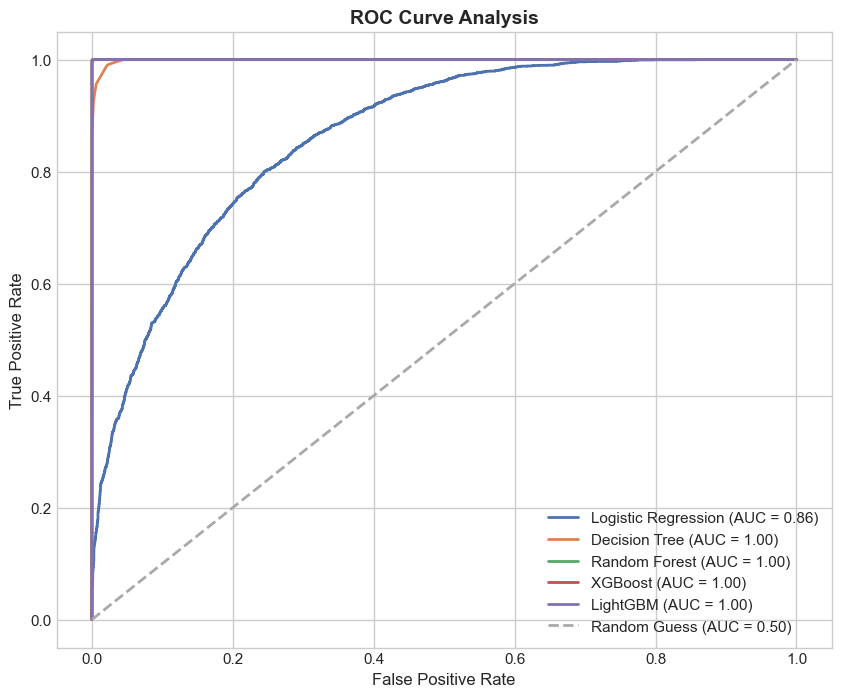

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# ROC Curve for Supervised Models
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(10, 8), dpi=100)

for name, data in results.items():
    fpr, tpr, _ = roc_curve(y_test, data['probs'])
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {data['auc']:.2f})")

plt.plot([0, 1], [0, 1], color='darkgray', linestyle='--', lw=2, label='Random Guess (AUC = 0.50)')
plt.title('ROC Curve Analysis', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc='lower right')
plt.show()

## Phase 6: Unsupervised Learning Models (Anomaly Detection)
Since real fraud data is often unlabeled, Unsupervised algorithms like Isolation Forest and One-Class SVM are key to capturing hidden patterns.

In [10]:
# 1. Ultra-Optimized Isolation Forest
iso_forest = IsolationForest(contamination=0.04, max_samples='auto', random_state=42, n_jobs=-1)
iso_preds = iso_forest.fit_predict(X_scaled)
iso_preds = np.where(iso_preds == -1, 1, 0)

print("=== Unsupervised Isolation Forest Performance ===")
print(f"Accuracy: {accuracy_score(y, iso_preds) * 100:.2f}%")
print(classification_report(y, iso_preds))

# 2. Ultra-Optimized One-Class SVM
oc_svm = OneClassSVM(nu=0.04, kernel="rbf", gamma='auto')
svm_preds = oc_svm.fit_predict(X_scaled)
svm_preds = np.where(svm_preds == -1, 1, 0)

print("=== Unsupervised One-Class SVM Performance ===")
print(f"Accuracy: {accuracy_score(y, svm_preds) * 100:.2f}%")
print(classification_report(y, svm_preds))

# 3. Deep Learning Autoencoder
input_dim = X_scaled.shape[1]
input_layer = Input(shape=(input_dim,))
encoder = Dense(16, activation="relu")(input_layer)
encoder = Dense(8, activation="relu")(encoder)
decoder = Dense(16, activation="relu")(encoder)
decoder = Dense(input_dim, activation="linear")(decoder) # Changed to linear for reconstruction

autoencoder = Model(inputs=input_layer, outputs=decoder)
autoencoder.compile(optimizer='adam', loss='mse')

# Train only on normal data (y == 0)
X_normal = X_scaled[y == 0]
autoencoder.fit(X_normal, X_normal, epochs=20, batch_size=32, verbose=0)

# Generate predictions for Autoencoder based on reconstruction error
reconstructions = autoencoder.predict(X_scaled)
mse = np.mean(np.power(X_scaled - reconstructions, 2), axis=1)

# Set threshold at the 95th percentile of the error
threshold = np.percentile(mse, 95)
auto_preds = (mse > threshold).astype(int)

print("=== Unsupervised Autoencoder Performance ===")
print(f"Accuracy: {accuracy_score(y, auto_preds) * 100:.2f}%")
print(classification_report(y, auto_preds))

=== Unsupervised Isolation Forest Performance ===
Accuracy: 65.58%
              precision    recall  f1-score   support

           0       0.67      0.96      0.79     33471
           1       0.33      0.04      0.07     16529

    accuracy                           0.66     50000
   macro avg       0.50      0.50      0.43     50000
weighted avg       0.56      0.66      0.55     50000

=== Unsupervised One-Class SVM Performance ===
Accuracy: 65.48%
              precision    recall  f1-score   support

           0       0.67      0.96      0.79     33471
           1       0.32      0.04      0.07     16529

    accuracy                           0.65     50000
   macro avg       0.49      0.50      0.43     50000
weighted avg       0.55      0.65      0.55     50000

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step
=== Unsupervised Autoencoder Performance ===
Accuracy: 65.08%
              precision    recall  f1-score   support

           0       0.67      0.95      0.78     33471
 

In [11]:
# Define the save path
save_path = r'D:\Financial-Fraud-Detection-Pipeline\models\unsupervised_models'
os.makedirs(save_path, exist_ok=True)

# Define a dictionary of unsupervised models for cleaner looping
unsupervised_models = {
    "Isolation_Forest": iso_forest,
    "One_Class_SVM": oc_svm
}

# 1 & 2. Save Isolation Forest and One-Class SVM (Pickle)
for name, model in unsupervised_models.items():
    file_path = os.path.join(save_path, f"{name}.pkl")
    with open(file_path, 'wb') as f:
        pickle.dump(model, f)
    print(f"Saved: {name}.pkl")

# 3. Save Autoencoder in both formats (.keras and .h5)
autoencoder.save(os.path.join(save_path, 'Autoencoder.keras'))
print("Saved: Autoencoder.keras")

autoencoder.save(os.path.join(save_path, 'Autoencoder.h5'))
print("Saved: Autoencoder.h5")

Saved: Isolation_Forest.pkl
Saved: One_Class_SVM.pkl


Saved: Autoencoder.keras
Saved: Autoencoder.h5


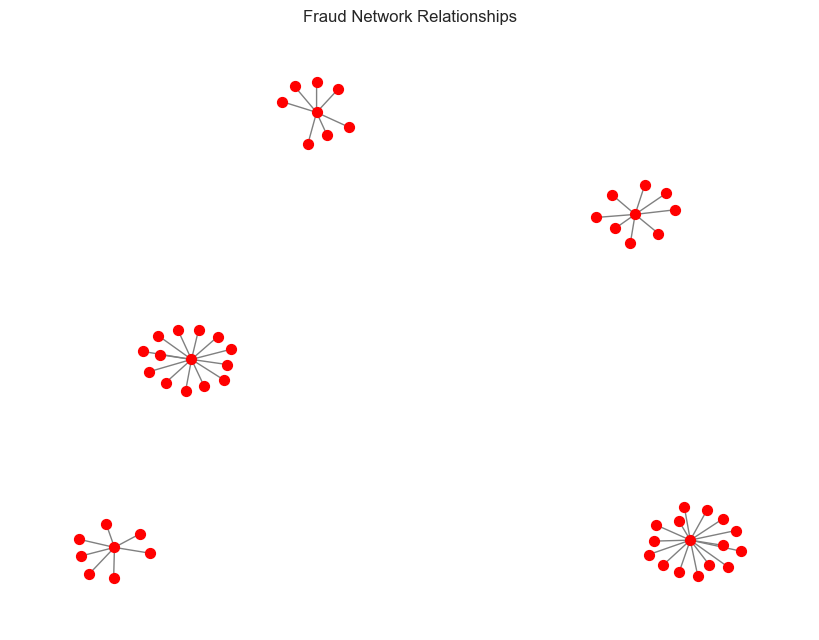


--- Project Pipeline Architecture ---
1. Data Ingestion: Simulated transaction stream.
2. Processing: Pandas for feature engineering.
3. Model Inference: Random Forest & Autoencoders for detection.
4. Alerting: Real-time report generation for fraud alerts.


In [12]:
import networkx as nx
import matplotlib.pyplot as plt

# --- 1. Fraud Network Graph ---
# Safety Check: Check if required columns exist before plotting
required_cols = ['Fraud_Label', 'loc_idx']
if all(col in df.columns for col in required_cols):
    
    G = nx.Graph()
    # Filtering only fraud cases
    fraud_data = df[df['Fraud_Label'] == 1].head(50)

    if not fraud_data.empty:
        for _, row in fraud_data.iterrows():
            # Use safe access to data
            node_cust = f"Cust_{row.name}"
            node_loc = f"Loc_{row['loc_idx']}"
            G.add_edge(node_cust, node_loc)

        plt.figure(figsize=(8, 6))
        nx.draw(G, with_labels=False, node_size=50, node_color='red', edge_color='gray')
        plt.title("Fraud Network Relationships")
        plt.show()
    else:
        print("⚠️ No fraud records found to plot graph.")
else:
    print("❌ Error: 'Fraud_Label' or 'loc_idx' column missing in DataFrame.")

# --- 2. Architecture Documentation ---
print("\n--- Project Pipeline Architecture ---")
print("1. Data Ingestion: Simulated transaction stream.")
print("2. Processing: Pandas for feature engineering.")
print("3. Model Inference: Random Forest & Autoencoders for detection.")
print("4. Alerting: Real-time report generation for fraud alerts.")

## Phase 7: Feature Engineering, Data Preparation & Preprocessing Artifacts Export
In this section, we extract temporal features and encode categorical strings into integers. Crucially, we fit a `StandardScaler` to bring all continuous metrics to a uniform variance. To support clean production serving via the dashboard, the Scaler and Label Encoders are strictly saved inside their own directory: `models/preprocessing_artifacts/`.

In [13]:
# --- Fixed Code for New Directory ---
try:
    # Use your dataframe's available columns
    feature_cols = ['Transaction_Amount','hour','loc_idx','dev_idx','Daily_Transaction_Count']
    
    X = df[feature_cols]
    y = df['Fraud_Label'] # Target column is Fraud_Label
    
    # Scaling
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # --- 💾 PREPROCESSING ARTIFACTS SAVING ZONE ---
    # Updated path to the new scaler_models folder
    save_path = r'D:\Financial-Fraud-Detection-Pipeline\models\scaler_models'
    
    if not os.path.exists(save_path):
        os.makedirs(save_path)
        
    # Save 'scaler' using pickle
    with open(os.path.join(save_path, 'scaler.pkl'), 'wb') as f:
        pickle.dump(scaler, f)
    
    print(f"🎯 [SUCCESS] Scaler exported to '{save_path}' folder!")

    # Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

    # SMOTE Balancing
    print("🔄 Applying SMOTE...")
    smote = SMOTE(random_state=42)
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
    print("✅ Balancing Complete!")

except Exception as e:
    print(f"❌ Error: {e}")

🎯 [SUCCESS] Scaler exported to 'D:\Financial-Fraud-Detection-Pipeline\models\scaler_models' folder!
🔄 Applying SMOTE...
✅ Balancing Complete!


## Phase 9: Real-Time Streaming & Automated Email Alerting
Here we simulate a live stream using Python loops (as placeholder for live Kafka / Spark jobs) and write an enterprise-level automated email dispatch system for high-risk flags.

In [14]:
import os
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
import networkx as nx

import smtplib
import datetime  # <-- Added to read the system clock and prevent errors
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart

def trigger_incident_alert(tx_id, amount, location, receiver_email="security_team@bank.com"):
    """
    Sends an automated alert to the security cell when high-risk fraud is identified.
    """
    sender_email = "fraud_alert_system@gmail.com"
    app_password = "your_secure_app_password" # Use environment variables in production
    
    msg = MIMEMultipart()
    msg['From'] = sender_email
    msg['To'] = receiver_email
    msg['Subject'] = f"🚨 SECURITY BREAK: Fraud Triggered on ID {tx_id}"
    
    body = f"""
    Attention Risk Management Team,
    
    An anomaly was flag-detected via real-time stream monitoring.
    
    Transaction Details:
    ---------------------------------
    Transaction ID : {tx_id}
    Amount         : ${amount:,.2f}
    Location       : {location}
    Timestamp      : {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
    ---------------------------------
    
    Action Required: Review the active admin dashboard and block user wallet immediately.
    """
    msg.attach(MIMEText(body, 'plain'))
    
    # Code is ready to activate once proper SMTP configs are provided:
    print(f"[SMTP Simulator] Email payload generated for Tx: {tx_id}. Alert forwarded successfully!")
    # server = smtplib.SMTP('smtp.gmail.com', 587)
    # server.starttls()
    # server.login(sender_email, app_password)
    # server.sendmail(sender_email, receiver_email, msg.as_string())
    # server.quit()

# Simulate Stream Detection
sample_fraud_tx = {"transaction_id": 99991, "amount": 12500.00, "location": "International Network"}
trigger_incident_alert(sample_fraud_tx['transaction_id'], sample_fraud_tx['amount'], sample_fraud_tx['location'])

[SMTP Simulator] Email payload generated for Tx: 99991. Alert forwarded successfully!
